# Processing Puromycin Data

____

In [ ]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH
# Add repo root to path for utilities
import sys
repo_root = Path().resolve().parents[1]  # Inhibitors -> notebooks -> cof_paper
sys.path.insert(0, str(repo_root))
import utilities as ld


## Data Configuration
___

In [ ]:
# Loading data
        #RMS External Drive Location:    'r'E:/Co-translational folding (CoF) paper/Puro Analysis/Fig 1J_Puro_6x Reporters'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/co-translational folding paper/Fig 1/1J_6x puro assays/6x Puro Analysis

data_dir = Path(r'E:/Co-translational folding (CoF) paper/Puro Analysis/Fig 1J_Puro_6x Reporters')


list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    data_dir,
    process_individual_days=False,
)
print(list_folder_substrings)
print(list_names)


Found 3 plasmids in 30 folders
  pNZ212: 3 experiment(s)
  pNZ370: 2 experiment(s)
  pNZ381: 2 experiment(s)
['pNZ212', 'pNZ370', 'pNZ381']
['6sfGFP', '6GFPuv', '6mCh']


## Processing & Plotting Configuration
___

In [ ]:
# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
frame_interval_sec = 20
use_sem = True
show_summary = False
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None
normalization_method = None  # options: 'mean', 'minmax', 'percentile', None
percentile_range = None      # only used with normalization_method='percentile'
treatment_label = 'Puromycin'

# ── What to Report ────────────────────────────────────────
report_spots = True  # True = number of spots; False = intensity

# ── Plotting Parameters ───────────────────────────────────
figsize = (5, 5)
ylims = (-20, 800) if not report_spots else (0, 1.1)
xlims = (-1.5, 15)
show_runoff_time = False
show_treatment_line = False
threshold_percentage_for_runoff = 0.1
results_folder = Path('Fig_1J_Puro')  # Set to a Path to save plots


## Plasmid Substrings
___

In [ ]:
substring_1 = 'pNZ212'
substring_2 = 'pNZ370'
substring_3 = 'pNZ381'


## Processing & Plotting
___

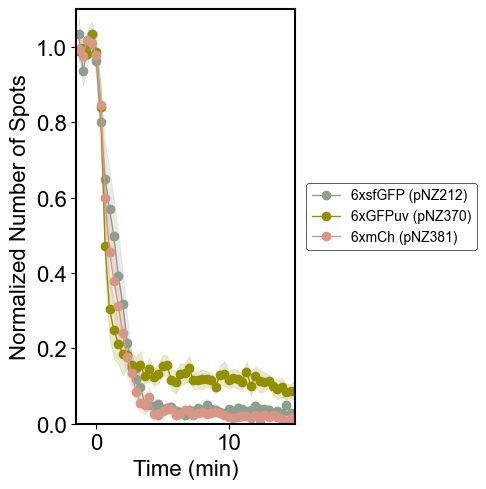

[None, None, None]

In [ ]:
selected_field = 'spot_int_ch_1'

# ── Process all three plasmids ────────────────────────────
process_kwargs = dict(
    data_dir=data_dir,
    inhibitor_frame_index=inhibitor_frame_index,
    selected_field=selected_field,
    use_sem=use_sem,
    show_summary=show_summary,
    max_percentage_threshold_after_treatment=max_percentage_threshold_after_treatment,
    frame_interval_sec=frame_interval_sec,
    normalization_method=normalization_method,
    percentile_range=percentile_range,
)

responding_indices_1, frames_1, intensities_1, spots_per_frame_1, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_1, **process_kwargs,
)
responding_indices_2, frames_2, intensities_2, spots_per_frame_2, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_2, **process_kwargs,
)
responding_indices_3, frames_3, intensities_3, spots_per_frame_3, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_3, **process_kwargs,
)

# ── Select data to plot ───────────────────────────────────
if report_spots:
    data_1, data_2, data_3 = spots_per_frame_1, spots_per_frame_2, spots_per_frame_3
    y_label = 'Normalized Number of Spots'
else:
    data_1, data_2, data_3 = intensities_1, intensities_2, intensities_3
    y_label = 'Norm. Intensity' if normalization_method else 'Intensity'

# ── Plot ──────────────────────────────────────────────────
INH.plot_multiple_inhibitors(
    full_frames_list=[frames_1, frames_2, frames_3],
    intensities_normalized_list=[data_1, data_2, data_3],
    inhibitor_frame_index=inhibitor_frame_index,
    legend_labels=['6xsfGFP (pNZ212)', '6xGFPuv (pNZ370)', '6xmCh (pNZ381)'],
    colors=["#8E9E8F", '#929000', '#D99686'],
    figsize=figsize,
    plot_name='Nascent_Chains_Comparison',
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
    show_runoff_time=show_runoff_time,
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    ylims=ylims,
    xlims=xlims,
    show_treatment_line=show_treatment_line,
    y_label=y_label,
    treatment_label=treatment_label,
    results_folder=results_folder,
    
)
